<a href="https://colab.research.google.com/github/Afrin-mte/OIBSIP/blob/main/Task_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Fraud Detection on Credit Card Transaction**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
df=pd.read_csv('creditcard.csv')
df.head()
df.shape
df.info()
df.isnull().sum()
df.describe()
df['Class'].value_counts


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162557 entries, 0 to 162556
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    162557 non-null  float64
 1   V1      162557 non-null  float64
 2   V2      162557 non-null  float64
 3   V3      162557 non-null  float64
 4   V4      162557 non-null  float64
 5   V5      162557 non-null  float64
 6   V6      162557 non-null  float64
 7   V7      162557 non-null  float64
 8   V8      162557 non-null  float64
 9   V9      162557 non-null  float64
 10  V10     162557 non-null  float64
 11  V11     162557 non-null  float64
 12  V12     162557 non-null  float64
 13  V13     162557 non-null  float64
 14  V14     162557 non-null  float64
 15  V15     162557 non-null  float64
 16  V16     162557 non-null  float64
 17  V17     162557 non-null  float64
 18  V18     162557 non-null  float64
 19  V19     162557 non-null  float64
 20  V20     162557 non-null  float64
 21  V21     16

<bound method IndexOpsMixin.value_counts of 0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
162552    0.0
162553    0.0
162554    0.0
162555    0.0
162556    NaN
Name: Class, Length: 162557, dtype: float64>

**Some basic info of the dataset**

In [ ]:
print("Columns:", df.columns.tolist())
print("\nMissing values:", df.isnull().sum().sum())
print("\nClass distribution:")
print(df['Class'].value_counts())
print("\nFraud in %:", round(df['Class'].mean() * 100, 3), "%")

Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Missing values: 3

Class distribution:
Class
0.0    162200
1.0       356
Name: count, dtype: int64

Fraud in %: 0.219 %


**Visualizing the class imbalance**

/tmp/ipykernel_1298/1699662201.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df,palette=['steelblue','crimson'])


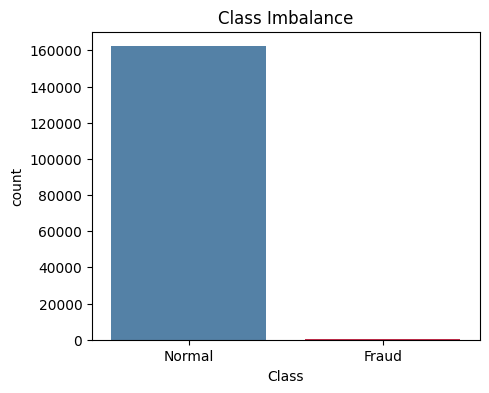

In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(x='Class', data=df,palette=['steelblue','crimson'])
plt.xticks([0,1],['Normal','Fraud'])
plt.title('Class Imbalance')
plt.show()


**Fraud vs Normal Amount**

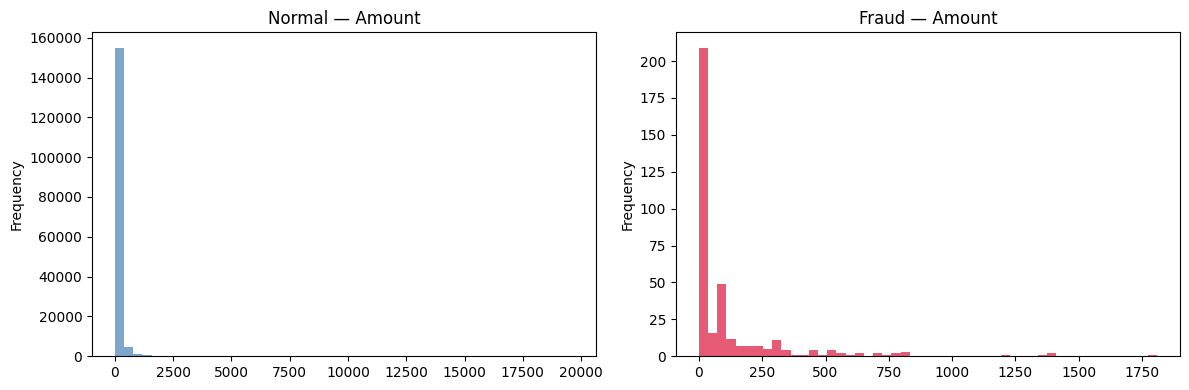

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df[df['Class'] == 0]['Amount'].plot(kind='hist', bins=50, ax=axes[0],
                                    color='steelblue', alpha=0.7, title='Normal — Amount')
df[df['Class'] == 1]['Amount'].plot(kind='hist', bins=50, ax=axes[1],
                                    color='crimson', alpha=0.7, title='Fraud — Amount')
plt.tight_layout()
plt.show()

**Correlation Heatmap**

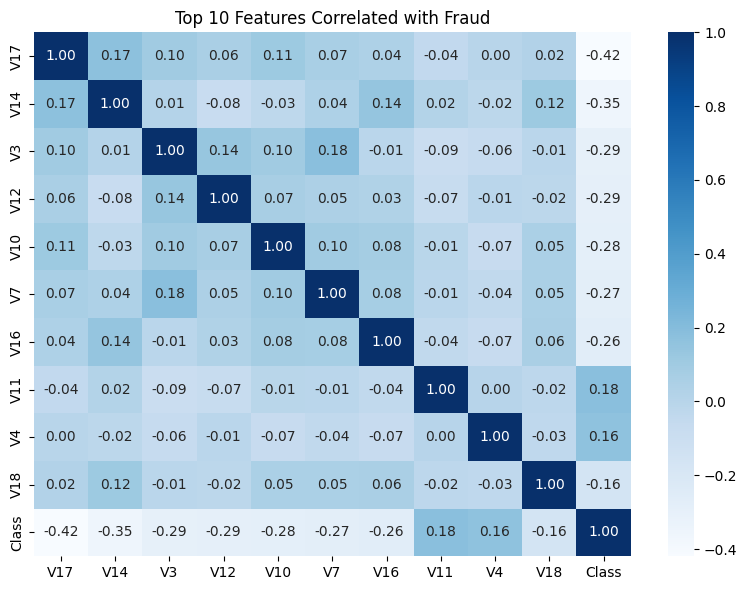

In [ ]:
top_features = df.corr()['Class'].drop('Class').abs().sort_values(ascending=False).head(10).index.tolist()

plt.figure(figsize=(8, 6))
sns.heatmap(df[top_features + ['Class']].corr(), annot=True, fmt='.2f', cmap='Blues')
plt.title('Top 10 Features Correlated with Fraud')
plt.tight_layout()
plt.show()

**Feature Engineering (Scale Amount & Time)**

In [ ]:
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled']   = scaler.fit_transform(df[['Time']])
df_clean = df.drop(columns=['Amount', 'Time'])
print("Clean shape:", df_clean.shape)

Clean shape: (162557, 31)


**Train/Test Split**

In [ ]:
df_clean_no_nan = df_clean.dropna(subset=['Class'])
X = df_clean_no_nan.drop('Class', axis=1)
y = df_clean_no_nan['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train:", X_train.shape)
print("Test: ", X_test.shape)

Train: (130044, 30)
Test:  (32512, 30)


**SMOTE - Fixes Imbalance**

In [ ]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", pd.Series(y_train_res).value_counts().to_dict())

Before SMOTE: {0.0: 129759, 1.0: 285}
After SMOTE:  {0.0: 129759, 1.0: 129759}


**Logistic Regression**

In [ ]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_res, y_train_res)
y_pred_lr = lr.predict(X_test)
print("Accuracy: ", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr, target_names=['Normal', 'Fraud']))

Accuracy:  0.976193405511811
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99     32441
       Fraud       0.08      0.92      0.14        71

    accuracy                           0.98     32512
   macro avg       0.54      0.95      0.57     32512
weighted avg       1.00      0.98      0.99     32512



**Decision Tree**

In [ ]:
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train_res, y_train_res)
y_pred_dt = dt.predict(X_test)
print(classification_report(y_test, y_pred_dt, target_names=['Normal', 'Fraud']))

              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99     32441
       Fraud       0.15      0.80      0.26        71

    accuracy                           0.99     32512
   macro avg       0.58      0.90      0.63     32512
weighted avg       1.00      0.99      0.99     32512



**Random Forest**

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_res, y_train_res)

y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'Fraud']))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     32441
       Fraud       0.92      0.77      0.84        71

    accuracy                           1.00     32512
   macro avg       0.96      0.89      0.92     32512
weighted avg       1.00      1.00      1.00     32512



**Confusion Matrices**

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, name, preds in zip(axes,
                            ['Logistic Regression', 'Decision Tree', 'Random Forest'],
                            [y_pred_lr, y_pred_dt, y_pred_rf]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

**ROC Curves**

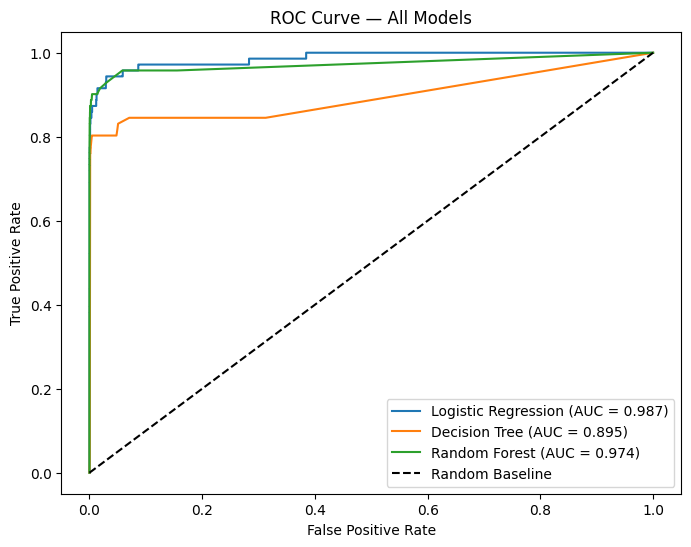

In [21]:
plt.figure(figsize=(8, 6))

for model, name in [(lr, 'Logistic Regression'), (dt, 'Decision Tree'), (rf, 'Random Forest')]:
    probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — All Models')
plt.legend()
plt.show()

**AUC -Area Under the Curve score table**

In [20]:
results = {}
for model, name in [(lr, 'Logistic Regression'), (dt, 'Decision Tree'), (rf, 'Random Forest')]:
    probs = model.predict_proba(X_test)[:, 1]
    results[name] = round(roc_auc_score(y_test, probs), 4)

results_df = pd.DataFrame(results.items(), columns=['Model', 'AUC Score'])
results_df = results_df.sort_values('AUC Score', ascending=False).reset_index(drop=True)
print(results_df)

                 Model  AUC Score
0  Logistic Regression     0.9868
1        Random Forest     0.9736
2        Decision Tree     0.8953


**Feature Importance**

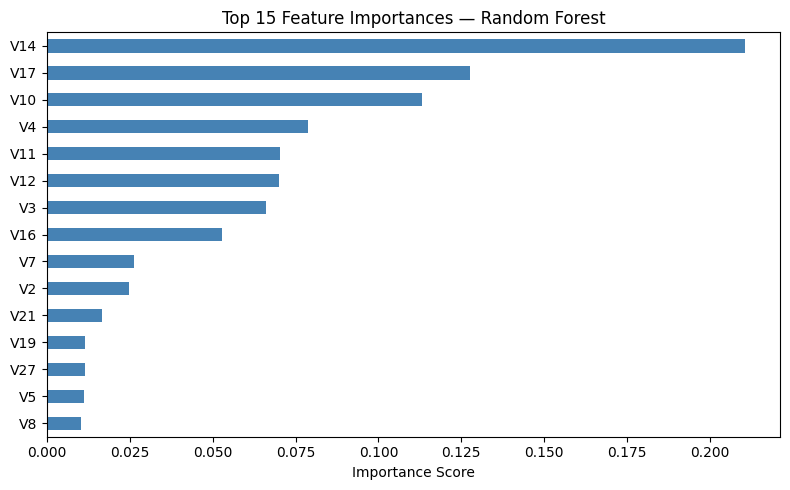

In [19]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top15 = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 5))
top15.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 15 Feature Importances — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

**Predict a Single Transaction**

In [23]:
sample     = X_test.iloc[[0]]
actual     = y_test.iloc[0]
prediction = rf.predict(sample)[0]
probability = rf.predict_proba(sample)[0][1]

print(f"Actual:  {'Fraud' if actual == 1 else 'Normal'}")
print(f"Predicted: {'Fraud' if prediction == 1 else 'Normal'}")
print(f"Fraud Probability: {probability:.4f}")

Actual:  Normal
Predicted: Normal
Fraud Probability: 0.0000


***Random Forest gives the Best AUC ~ 0.97+***